################################################################################
# PART 1 INTRODUCTION
################################################################################

---
# 🚢 Part 1: Supervised Learning — Binary Classification with the Titanic Dataset

## What is Supervised Learning?

**Supervised learning** is the most common category of machine learning. The term "supervised" refers to the fact that we are training a model on **labeled data** — a dataset where each input example already has a known, correct output (the label or target variable).

The model learns a mapping function `f(X) → y`, where `X` is a matrix of input features and `y` is the target vector. Once trained, the model can predict `y` for new, unseen inputs.

There are two major types:
- **Classification**: The target `y` is a discrete category (e.g., survived/not survived, spam/not spam, cat/dog). This is our focus here.
- **Regression**: The target `y` is a continuous number (e.g., house price, temperature).

### The Titanic Dataset

The Titanic dataset is one of the most famous introductory datasets in data science. It records information about **891 passengers** aboard the RMS Titanic, which sank on April 15, 1912 after colliding with an iceberg. Our goal is to **predict whether a passenger survived** (`survived = 1`) or did not survive (`survived = 0`) based on features like their age, class, sex, and family situation.

This is a **binary classification** problem. The historical data shows strong patterns — for example, women and children were given priority in lifeboats, and first-class passengers had better access to the upper decks near the lifeboats. Our models will learn these patterns from the data automatically.


In [66]:
################################################################################
# STAGE 1
################################################################################

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress minor warnings for cleaner output

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import LabelEncoder

# Load the Titanic dataset from Seaborn's built-in collection
df = sns.load_dataset('titanic')

print("📐 Dataset Shape:", df.shape)
print("\n📊 First 5 Rows:")
display(df.head())

print("\n📋 Column Data Types & Non-Null Counts:")
df.info()

print("\n🔍 Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

print("\n📈 Survival Rate:")
print(df['survived'].value_counts(normalize=True).rename({0: 'Did not survive', 1: 'Survived'}).map('{:.1%}'.format))


📐 Dataset Shape: (891, 15)

📊 First 5 Rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



📋 Column Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

🔍 Missing Values per Column:


,Missing Count,Missing %
age,177,19.9
embarked,2,0.2
deck,688,77.2
embark_town,2,0.2



📈 Survival Rate:
survived
Did not survive    61.6%
Survived           38.4%
Name: proportion, dtype: object


################################################################################
# STAGE 2  
################################################################################

---
## 🔧 Feature Engineering

### Why Feature Engineering Matters

Raw data is rarely in the perfect format for a machine learning model. **Feature engineering** is the process of transforming, combining, or creating new variables from the raw data to make patterns more explicit and accessible to the algorithm. Skilled feature engineering is often the single biggest driver of model performance — far more impactful than which algorithm you choose.

### What We Do in This Cell

**1. Handling Missing Values (Imputation)**

Real-world datasets almost always have missing values. We have two strategies here:
- **`age`**: ~19.9% of values are missing. We fill them with the **median** age (not the mean), because the median is robust to outliers. A few very old or very young passengers wouldn't skew the median the way they'd skew the mean.
- **`embarked`**: Only 2 values are missing. We fill with the **mode** (most frequent value), which is `'S'` (Southampton).

⚠️ *Important caveat*: In a rigorous production setting, you would compute the median/mode on the **training set only**, then apply it to the test set — to avoid data leakage. For this tutorial we do it on the full dataset for simplicity.

**2. Creating `family_size` and `is_alone`**

The raw dataset has two separate columns: `sibsp` (siblings/spouses aboard) and `parch` (parents/children aboard). Neither alone tells the full story. By combining them into `family_size = sibsp + parch + 1` (the `+1` accounts for the passenger themselves), we create a more meaningful feature. Research on the Titanic shows that large families (6+) had lower survival rates because they spent time searching for each other; solo travelers also had lower rates. A binary `is_alone` flag captures the solo-traveler signal cleanly.

**3. Extracting `title` from the name**

The passenger's name contains a social title (Mr., Mrs., Miss., Master., Dr., etc.) that encodes both **age range** and **social status** — two variables strongly linked to survival. We extract it using a **regular expression** (`r' ([A-Za-z]+)\.'`), which captures any word ending in a period after a space. We then group rare titles:
- `Mme`, `Mlle`, `Ms` → `Miss` (French/alternative forms of the same social role)
- `Dr`, `Rev`, `Col`, `Major`, `Capt` → `Officer` (all high-status professional roles)

Finally we encode titles as integers (0–4), since most ML models require numerical inputs.

**4. Encoding Categorical Variables**

Algorithms like Logistic Regression and Random Forest cannot directly use text like `'male'` or `'S'`. We use `LabelEncoder` to convert:
- `sex` → `sex_enc` (female=0, male=1)
- `embarked` → `embarked_enc` (C=0, Q=1, S=2)

Note: For variables with more than 2 categories and no ordinal relationship, **one-hot encoding** is often preferable to label encoding, as label encoding can imply a spurious ordering. We use label encoding here for simplicity.


✅ Available columns in seaborn Titanic:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'family_size', 'is_alone', 'who_enc', 'sex_enc', 'embarked_enc']

✅ Engineered features preview:


,sex,who,sibsp,parch,embarked,family_size,is_alone,who_enc,sex_enc,embarked_enc
0,male,man,1,0,S,2,0,0,1,2
1,female,woman,1,0,C,2,0,1,0,0
2,female,woman,0,0,S,1,1,1,0,2
3,female,woman,1,0,S,2,0,1,0,2
4,male,man,0,0,S,1,1,0,1,2
5,male,man,0,0,Q,1,1,0,1,1
6,male,man,0,0,S,1,1,0,1,2
7,male,child,3,1,S,5,0,2,1,2


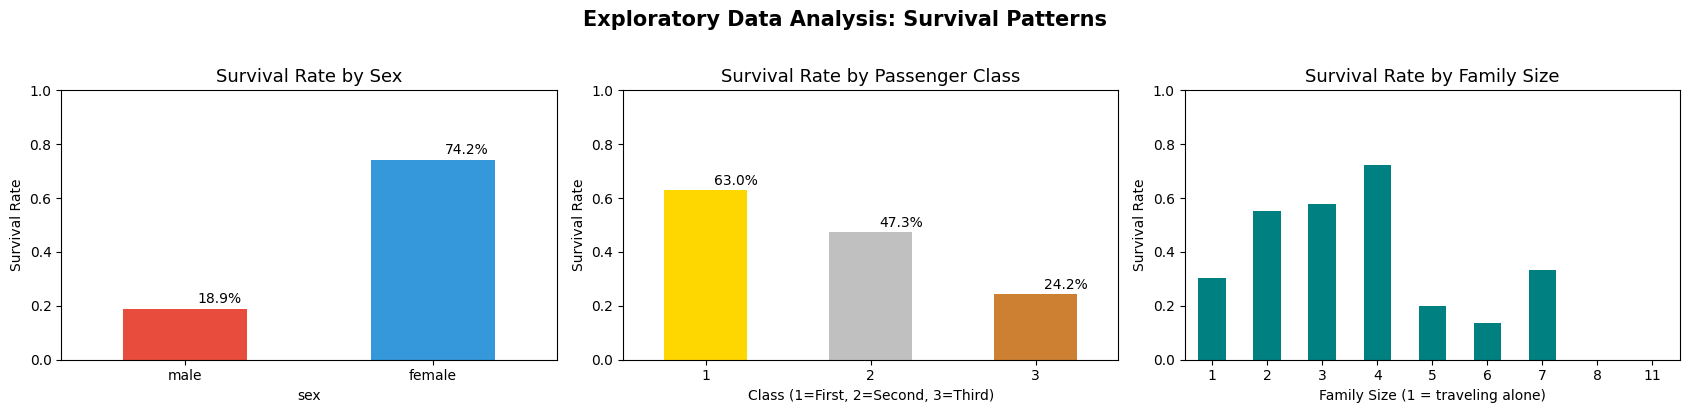

In [67]:
################################################################################
# STAGE 2
################################################################################

df_fe = df.copy()  # Always work on a copy to preserve the original data

# 1. Impute Missing Values
df_fe['age']      = df_fe['age'].fillna(df_fe['age'].median())
df_fe['embarked'] = df_fe['embarked'].fillna(df_fe['embarked'].mode()[0])
df_fe['fare']     = df_fe['fare'].fillna(df_fe['fare'].median())

# 2. Family Features
df_fe['family_size'] = df_fe['sibsp'] + df_fe['parch'] + 1
df_fe['is_alone']    = (df_fe['family_size'] == 1).astype(int)

# 3. 'who' encodes the same signal as titles: man / woman / child
#    (seaborn derives this from sex + age, so it captures the lifeboat-priority logic)
who_map = {'man': 0, 'woman': 1, 'child': 2}
df_fe['who_enc'] = df_fe['who'].map(who_map).fillna(0).astype(int)

# 4. Encode Categorical Variables
df_fe['sex_enc']      = LabelEncoder().fit_transform(df_fe['sex'])
df_fe['embarked_enc'] = LabelEncoder().fit_transform(df_fe['embarked'])

# Quick Summary
print("✅ Available columns in seaborn Titanic:")
print(list(df_fe.columns))

print("\n✅ Engineered features preview:")
display(df_fe[['sex', 'who', 'sibsp', 'parch', 'embarked',
               'family_size', 'is_alone', 'who_enc',
               'sex_enc', 'embarked_enc']].head(8))

# Visualise survival patterns
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Survival by Sex
sex_surv = df_fe.groupby('sex')['survived'].mean().sort_values()
sex_surv.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'], rot=0)
axes[0].set_title('Survival Rate by Sex', fontsize=13)
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + 0.3, p.get_height() + 0.02))

# Survival by Passenger Class
pclass_surv = df_fe.groupby('pclass')['survived'].mean()
pclass_surv.plot(kind='bar', ax=axes[1], color=['gold', 'silver', '#cd7f32'], rot=0)
axes[1].set_title('Survival Rate by Passenger Class', fontsize=13)
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Class (1=First, 2=Second, 3=Third)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + 0.3, p.get_height() + 0.02))

# Survival by Family Size
fam_surv = df_fe.groupby('family_size')['survived'].mean()
fam_surv.plot(kind='bar', ax=axes[2], color='teal', rot=0)
axes[2].set_title('Survival Rate by Family Size', fontsize=13)
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Family Size (1 = traveling alone)')

plt.suptitle('Exploratory Data Analysis: Survival Patterns',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

################################################################################
# STAGE 3  
################################################################################

---
## ✂️ Preparing Features & Splitting the Data

### Feature Selection

We select a subset of columns to use as model inputs (`features`). The goal is to include variables that are informative about survival while excluding:
- **Redundant columns**: e.g., `sex` (original text) after we've created `sex_enc` (encoded integer).
- **Leak columns**: e.g., `alive` (which literally encodes the same information as `survived`).
- **High-cardinality text**: e.g., `name`, `ticket`, `cabin` — these would require further processing.

Our final 8 features are: `pclass`, `age`, `fare`, `family_size`, `is_alone`, `sex_enc`, `embarked_enc`, `title`.

### The Train-Test Split: The Single Most Important Rule in ML

The golden rule of supervised learning is: **never evaluate your model on the same data it was trained on**.

Why? Because a model can "memorise" the training data (a phenomenon called **overfitting**) and appear to perform extremely well without having learned any genuinely generalisable pattern. If you test on the same data you trained on, you get an overly optimistic estimate of how the model will perform on new, real-world data.

The solution is to split the dataset:
- **Training set (80%)**: The model sees this data and learns from it.
- **Test set (20%)**: The model never sees this during training. We use it only at the very end to get an honest estimate of performance.

We use `stratify=y` to ensure that the proportion of survivors (38.4%) is the same in both the train and test sets. Without stratification, random chance could result in one set having many more survivors than the other.

We also set `random_state=42` so that the split is reproducible — running this notebook again produces identical splits.



In [68]:
################################################################################
# STAGE 3
################################################################################

features = ['pclass', 'age', 'fare', 'family_size', 'is_alone',
            'sex_enc', 'embarked_enc', 'who_enc']   # <-- 'title' replaced by 'who_enc'

X = df_fe[features].copy()
y = df_fe['survived']

# 80% train / 20% test — stratified so class balance is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total samples    : {len(X)}")
print(f"Training samples : {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Test samples     : {len(X_test)}  ({len(X_test)/len(X):.0%})")
print()
print("Survival rate in training set:", y_train.mean().round(3))
print("Survival rate in test set    :", y_test.mean().round(3))
print("→ Stratification confirmed: both sets have the same class balance.")

print("\nFeature matrix preview (X_train):")
display(X_train.head())


Total samples    : 891
Training samples : 712 (80%)
Test samples     : 179  (20%)

Survival rate in training set: 0.383
Survival rate in test set    : 0.385
→ Stratification confirmed: both sets have the same class balance.

Feature matrix preview (X_train):


,pclass,age,fare,family_size,is_alone,sex_enc,embarked_enc,who_enc
692,3,28.0,56.4958,1,1,1,2,0
481,2,28.0,0.0000,1,1,1,2,0
527,1,28.0,221.7792,1,1,1,2,0
855,3,18.0,9.3500,2,0,0,2,1
801,2,31.0,26.2500,3,0,0,2,1


################################################################################
# STAGE 4
################################################################################

---
## 🤖 Training & Comparing Three Classification Models

We will train and compare three different algorithms. Understanding their differences is essential for choosing the right tool for any given problem.

---

### 1. Logistic Regression

Despite its name, Logistic Regression is a **classification** algorithm, not a regression one. It models the probability that an example belongs to the positive class (survived=1) using the **sigmoid function**:

$$P(y=1|X) = \sigma(X\beta) = \frac{1}{1 + e^{-X\beta}}$$

Where `β` are the learned coefficients. The sigmoid squashes any real number into the range (0, 1), making it interpretable as a probability. If `P > 0.5`, we predict class 1 (survived).

**Strengths**: Fast to train, highly interpretable, works well when the relationship between features and target is roughly linear in log-odds space.

**Limitations**: Assumes a linear decision boundary; struggles with complex, non-linear patterns.

---

### 2. Random Forest

A Random Forest is an **ensemble method** built on **Decision Trees**. Here's how it works:

1. **Bootstrap sampling**: Draw `n` random samples from the training data *with replacement* (called "bagging"). Each tree gets a slightly different dataset.
2. **Random feature subsets**: At each split, only a random subset of features (`sqrt(n_features)` by default) is considered. This decorrelates the trees.
3. **Voting**: Each tree makes a prediction and the forest takes a **majority vote**.

The key insight is that many diverse, imperfect models aggregated together outperform any single model. Errors made by individual trees tend to cancel out, while correct predictions reinforce each other.

**Strengths**: Handles non-linear relationships, robust to outliers, provides feature importance scores, rarely overfits badly.

**Limitations**: Less interpretable than Logistic Regression (a "black box"), slower to train than a single tree.

---

### 3. Gradient Boosting

Like Random Forest, Gradient Boosting is also an ensemble of decision trees. The critical difference is that trees are built **sequentially**, not in parallel:

1. Start with a simple model (often just predicting the mean).
2. Compute the **residuals** (errors) of the current model.
3. Train a new tree to predict those residuals.
4. Add the new tree's predictions (scaled by a **learning rate** `η`) to the ensemble.
5. Repeat for `n_estimators` iterations.

Each new tree "corrects" the mistakes of all previous trees. The word "gradient" refers to gradient descent in function space — minimising a loss function by taking small steps in the direction that reduces error.

**Strengths**: Often the best-performing algorithm on tabular data; wins many Kaggle competitions.

**Limitations**: More hyperparameters to tune, prone to overfitting if not regularised, slower to train.

---

### Cross-Validation: A More Reliable Performance Estimate

A single train-test split can be "lucky" or "unlucky" depending on which samples ended up in each set. **5-fold cross-validation** gives a more robust estimate:

1. Split the training data into 5 equal "folds".
2. Train on folds 1–4, validate on fold 5. Record the score.
3. Train on folds 1–3,5, validate on fold 4. Record the score.
4. ...repeat for all 5 combinations.
5. Report the **mean** (and standard deviation) of the 5 scores.

We use `roc_auc` as our Cross-Validation (CV) scoring metric. **⚠️ Important**: Cross-validation is done only on the training data. The test set is still held out.


In [69]:
################################################################################
# STAGE 4
################################################################################

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=10, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
}

results = {}

for name, model in models.items():
    # 1. Train on training set
    model.fit(X_train, y_train)

    # 2. Predict on the held-out test set
    y_pred = model.predict(X_test)

    # 3. 5-fold cross-validation on training data only
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()

    # 4. Test AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)

    results[name] = {'cv_auc': cv_mean, 'cv_std': cv_std, 'test_auc': test_auc}

    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))
    print(f"  5-Fold CV AUC : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Test AUC      : {test_auc:.4f}")

# Summary Table
print("\n" + "="*55)
print("  SUMMARY TABLE")
print("="*55)
summary_df = pd.DataFrame(results).T
summary_df.columns = ['CV AUC (mean)', 'CV AUC (std)', 'Test AUC']
summary_df = summary_df.sort_values('Test AUC', ascending=False)
display(summary_df.round(4))
print("\n💡 Reading the metrics:")
print("  • Precision: Of all passengers the model predicted as 'survived', what % actually survived?")
print("  • Recall:    Of all passengers who actually survived, what % did the model catch?")
print("  • F1-Score:  Harmonic mean of precision and recall. Useful when classes are imbalanced.")
print("  • AUC:       Area Under the ROC Curve — ranges 0.5 (random) to 1.0 (perfect).")



  Model: Logistic Regression
                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179

  5-Fold CV AUC : 0.8600 ± 0.0170
  Test AUC      : 0.8706

  Model: Random Forest
                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179

  5-Fold CV AUC : 0.8318 ± 0.0424
  Test AUC      : 0.8399

  Model: Gradient Boosting
                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85      

,CV AUC (mean),CV AUC (std),Test AUC
Logistic Regression,0.8600,0.0170,0.8706
Gradient Boosting,0.8771,0.0316,0.8504
Random Forest,0.8318,0.0424,0.8399



💡 Reading the metrics:
  • Precision: Of all passengers the model predicted as 'survived', what % actually survived?
  • Recall:    Of all passengers who actually survived, what % did the model catch?
  • F1-Score:  Harmonic mean of precision and recall. Useful when classes are imbalanced.
  • AUC:       Area Under the ROC Curve — ranges 0.5 (random) to 1.0 (perfect).


################################################################################
# STAGE 5  
################################################################################

---
## 🌟 Feature Importance

### What is Feature Importance?

After training a Random Forest, we can ask: **which features did the model rely on most?** This is called **feature importance** (also known as variable importance or feature relevance).

Random Forest computes feature importance using **Mean Decrease in Impurity (MDI)**: for each feature, we sum up how much that feature reduced the **Gini impurity** (a measure of disorder) across all trees and all splits. A feature that is used frequently at high levels of the tree and consistently separates the classes well will have a high importance score.

The scores are normalised so that they **sum to 1.0** (or 100%), giving us a relative ranking.

### Interpreting the Results

We expect to see `sex_enc` near the top — the historical record overwhelmingly shows that "women and children first" was the dominant rule in lifeboat allocation. `fare` and `pclass` both serve as proxies for **socioeconomic status**, which correlates with cabin location, deck access, and awareness of emergency procedures.

⚠️ **Important caveat**: MDI feature importance can be biased toward **high-cardinality features** (features with many unique values, like `age` and `fare`). More robust alternatives include **Permutation Importance** (which measures how much the score drops when a feature's values are randomly shuffled) or **SHAP values** (which attribute contributions for each individual prediction).


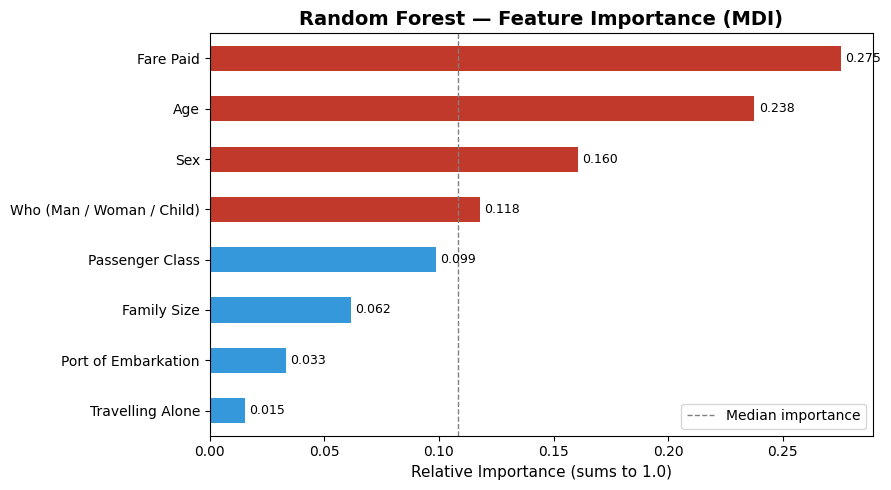


🔑 Key Insight:
  The most important feature is 'Fare Paid'.
  This aligns with historical accounts: women and children were prioritised for lifeboats.


In [70]:
################################################################################
# STAGE 5
################################################################################

rf = models['Random Forest']

importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

# Human-readable labels — must match the features list exactly
label_map = {
    'pclass':       'Passenger Class',
    'age':          'Age',
    'fare':         'Fare Paid',
    'family_size':  'Family Size',
    'is_alone':     'Travelling Alone',
    'sex_enc':      'Sex',
    'embarked_enc': 'Port of Embarkation',
    'who_enc':      'Who (Man / Woman / Child)'   # <-- was 'title'
}
importance.index = [label_map[i] for i in importance.index]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if v > importance.median() else '#3498db' for v in importance.values]
importance.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Random Forest — Feature Importance (MDI)', fontsize=14, fontweight='bold')
ax.set_xlabel('Relative Importance (sums to 1.0)', fontsize=11)
ax.axvline(importance.median(), color='gray', linestyle='--', linewidth=1, label='Median importance')
ax.legend()

for val, patch in zip(importance.values, ax.patches):
    ax.text(val + 0.002, patch.get_y() + patch.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n🔑 Key Insight:")
top_feature = importance.idxmax()
print(f"  The most important feature is '{top_feature}'.")
print("  This aligns with historical accounts: women and children were prioritised for lifeboats.")


################################################################################
# STAGE 6   
################################################################################

---
## 📊 Confusion Matrix & ROC Curves

### The Confusion Matrix

A **confusion matrix** is a 2×2 table that breaks down a classifier's predictions into four categories:

|                    | **Predicted: Did Not Survive** | **Predicted: Survived** |
|--------------------|-------------------------------|-------------------------|
| **Actual: Did Not Survive** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual: Survived** | False Negative (FN) ❌ | True Positive (TP) ✅ |

From these four cells we derive all our key metrics:
- **Accuracy** = (TP + TN) / Total
- **Precision** = TP / (TP + FP) — "Of those the model said survived, how many did?"
- **Recall** = TP / (TP + FN) — "Of those who actually survived, how many did the model find?"
- **F1 Score** = 2 × (Precision × Recall) / (Precision + Recall)

### The ROC Curve and AUC

A classifier doesn't just output class labels (0 or 1) — it first outputs a **probability** (e.g., "72% chance this passenger survived"). We then apply a **threshold** (typically 0.5) to convert the probability into a binary prediction.

The **Receiver Operating Characteristic (ROC) curve** visualises how the trade-off between **True Positive Rate (Recall)** and **False Positive Rate** changes as we slide the threshold from 0 to 1:

- At threshold = 0: Predict everyone as "survived" → TPR = 1.0, FPR = 1.0
- At threshold = 1: Predict nobody as "survived" → TPR = 0.0, FPR = 0.0
- A **random classifier** produces a straight diagonal line from (0,0) to (1,1).
- A **perfect classifier** goes straight up to (0,1) then across to (1,1).

The **AUC (Area Under the ROC Curve)** summarises the entire curve in one number:
- AUC = 0.5 → no better than random guessing
- AUC = 1.0 → perfect classification
- AUC = 0.85 → roughly, an 85% probability that the model ranks a random positive example higher than a random negative example.

AUC is threshold-independent and works well even with imbalanced classes.



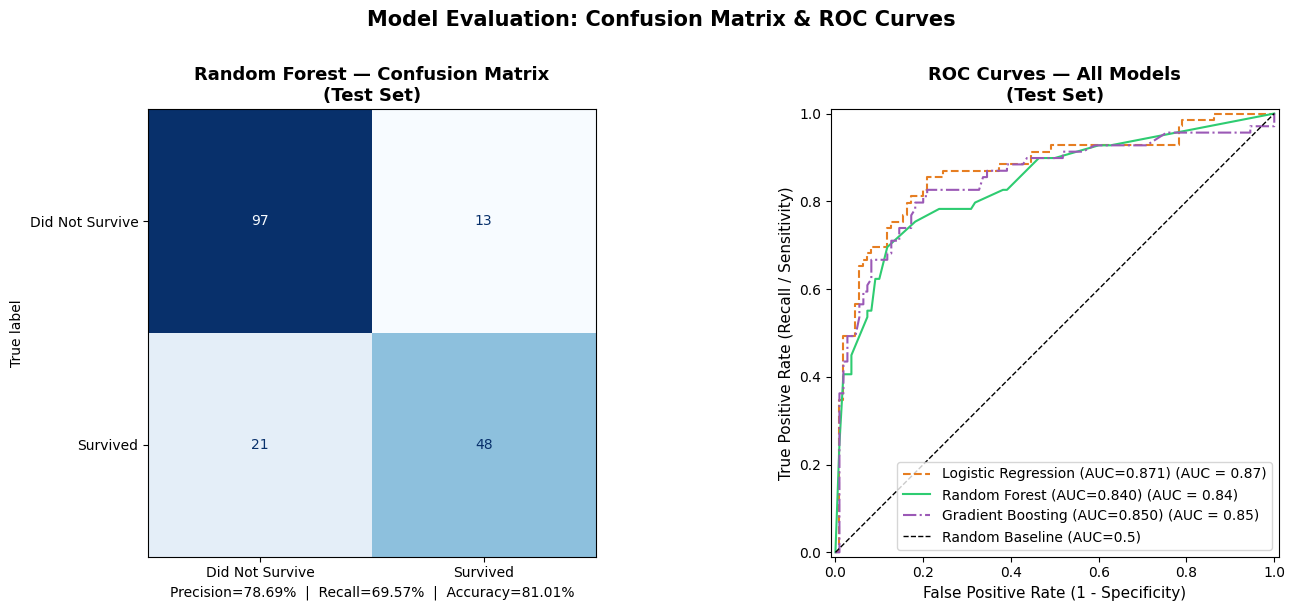

In [71]:
################################################################################
# STAGE 6.a
################################################################################

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Confusion Matrix for Random Forest
rf = models['Random Forest']
y_pred_rf = rf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    ax=axes[0],
    display_labels=['Did Not Survive', 'Survived'],
    colorbar=False,
    cmap='Blues'
)
axes[0].set_title('Random Forest — Confusion Matrix\n(Test Set)', fontsize=13, fontweight='bold')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
total = tn + fp + fn + tp
axes[0].set_xlabel(
    f'Precision={tp/(tp+fp):.2%}  |  Recall={tp/(tp+fn):.2%}  |  Accuracy={(tp+tn)/total:.2%}',
    fontsize=10
)

# Right: ROC Curves for all three models
line_styles = {'Logistic Regression': '--', 'Random Forest': '-', 'Gradient Boosting': '-.'}
colors_roc  = {'Logistic Regression': '#e67e22', 'Random Forest': '#2ecc71', 'Gradient Boosting': '#9b59b6'}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=f'{name} (AUC={auc:.3f})',
        ax=axes[1],
        linestyle=line_styles[name],
        color=colors_roc[name]
    )

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline (AUC=0.5)')
axes[1].set_title('ROC Curves — All Models\n(Test Set)', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)

plt.suptitle('Model Evaluation: Confusion Matrix & ROC Curves', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


################################################################################
# PART 2 INTRODUCTION
################################################################################

---
# ⚙️ Part 2: Model Optimisation — Hyperparameter Tuning

## What is a Hyperparameter?

Every ML model has two kinds of parameters:
- **Model parameters**: Learned during training from the data (e.g., the weights `β` in logistic regression, the split thresholds in decision trees).
- **Hyperparameters**: Set *before* training begins, not learned from data (e.g., `n_estimators`, `max_depth` in Random Forest).

The choice of hyperparameters significantly affects model performance. The process of finding the best combination is called **hyperparameter tuning**.

## GridSearchCV: Exhaustive Search

**GridSearchCV** tests every possible combination of hyperparameter values from a predefined grid. For example, if we have:
- `n_estimators`: [50, 100, 200] → 3 options
- `max_depth`: [3, 5, 10, None] → 4 options
- `min_samples_split`: [2, 5, 10] → 3 options
- `max_features`: ['sqrt', 'log2'] → 2 options

Total combinations: 3 × 4 × 3 × 2 = **72 models**. With 5-fold cross-validation, that's 72 × 5 = **360 training runs**.

Each combination is evaluated by cross-validation (on the training set only), and the best combination is selected.

### ⚠️ The Critical Rule: Never Evaluate on the Test Set Until the End

This is the most common mistake made by beginners:

If you use the test set to pick hyperparameters (e.g., "let me try 50 trees vs 100 trees and see which does better on the test set"), you have **implicitly trained on the test set**. Your test set performance will be optimistically biased.

The correct workflow is:
1. Split data → Train / Test
2. Use **cross-validation on the training set** to select hyperparameters.
3. Train the best model on the **full training set**.
4. Evaluate **once** on the test set — this is your final, honest performance estimate.

GridSearchCV enforces this workflow automatically.

🔍 Running GridSearchCV — this may take 1–2 minutes...
   (72 parameter combinations × 5-fold CV = 360 model fits)

Feature matrix preview (X_train):


,pclass,age,fare,family_size,is_alone,sex_enc,embarked_enc,who_enc
692,3,28.0,56.4958,1,1,1,2,0
481,2,28.0,0.0000,1,1,1,2,0
527,1,28.0,221.7792,1,1,1,2,0
855,3,18.0,9.3500,2,0,0,2,1
801,2,31.0,26.2500,3,0,0,2,1



✅ Search complete!

📌 Best Hyperparameters Found:
   max_depth                : 5
   max_features             : sqrt
   min_samples_split        : 2
   n_estimators             : 50

   Best CV AUC (training set): 0.8758

  Test Set AUC Comparison:
  Baseline Random Forest (default params) : 0.8399
  Tuned Random Forest (GridSearchCV)       : 0.8474
  ✅ Improvement: +0.0075 AUC (0.89% relative gain)


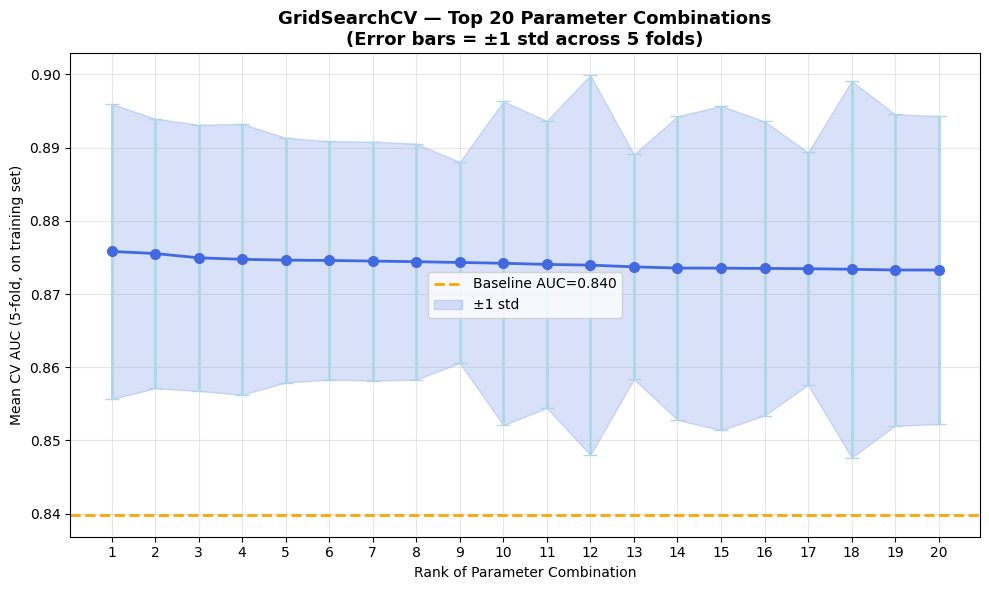


💡 Key Takeaways:
   1. The top 20 combinations have very similar AUCs — the model is robust to hyperparameter choices.
   2. Error bars (±1 std) overlap heavily, meaning ranking between similar configs is partly due to luck.
   3. Always use cross-validation to tune hyperparameters, and report final performance on a held-out test set.


In [72]:
################################################################################
# STAGE 6.b
################################################################################

print("🔍 Running GridSearchCV — this may take 1–2 minutes...")
print("   (72 parameter combinations × 5-fold CV = 360 model fits)")

print("\nFeature matrix preview (X_train):")
display(X_train.head())

# -------------------------------------------------------------------
# Hyperparameter grid for RandomForestClassifier tuning
# -------------------------------------------------------------------
# We define a set of values for key Random Forest parameters.
# GridSearchCV will train models using ALL combinations to find
# the best-performing configuration via cross-validation.
#
# Total combinations:
# 3 (n_estimators) × 4 (max_depth) × 3 (min_samples_split) × 2 (max_features) = 72
# -------------------------------------------------------------------

param_grid = {

    # Number of trees in the forest.
    # More trees → more stable predictions but longer training time.
    # Typical trade-off: performance vs. speed.
    'n_estimators': [50, 100, 200],

    # Maximum depth of each decision tree.
    # Controls model complexity:
    #   - Small depth → simpler model, less overfitting.
    #   - Large depth → more complex patterns, risk of overfitting.
    #   - None → grow trees until pure (can overfit).
    'max_depth': [3, 5, 10, None],

    # Minimum number of samples required to split an internal node.
    # Prevents trees from learning overly specific rules.
    #   - 2 → splits easily (complex trees).
    #   - Higher values → more generalised trees.
    'min_samples_split': [2, 5, 10],

    # Number of features considered when looking for the best split.
    # Adds randomness → reduces correlation between trees.
    #   'sqrt' → √(total_features)
    #   'log2' → log2(total_features)
    'max_features': ['sqrt', 'log2'],
}

# IMPORTANT: We pass X_train and y_train only — NOT the test set!
gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,   # Use all available CPU cores for speed
    verbose=0
)
gs.fit(X_train, y_train)

print("\n✅ Search complete!")
print("\n📌 Best Hyperparameters Found:")
for param, val in gs.best_params_.items():
    print(f"   {param:25s}: {val}")
print(f"\n   Best CV AUC (training set): {gs.best_score_:.4f}")

# Compare baseline vs tuned model on the test set
baseline_rf = models['Random Forest']   # Already trained in Cell 4
best_rf     = gs.best_estimator_        # Best model from GridSearch

baseline_auc = roc_auc_score(y_test, baseline_rf.predict_proba(X_test)[:, 1])
tuned_auc    = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

print(f"\n{'='*50}")
print(f"  Test Set AUC Comparison:")
print(f"{'='*50}")
print(f"  Baseline Random Forest (default params) : {baseline_auc:.4f}")
print(f"  Tuned Random Forest (GridSearchCV)       : {tuned_auc:.4f}")
delta = tuned_auc - baseline_auc
if delta > 0:
    print(f"  ✅ Improvement: +{delta:.4f} AUC ({delta/baseline_auc:.2%} relative gain)")
else:
    print(f"  ℹ️  No improvement ({delta:.4f}). Default params were already near-optimal for this dataset size.")

# Visualise top 20 parameter combinations
cv_results = pd.DataFrame(gs.cv_results_)
top20 = cv_results.nlargest(20, 'mean_test_score')

fig, ax = plt.subplots(figsize=(10, 6))
x_vals  = range(1, 21)
y_means = top20['mean_test_score'].values
y_stds  = top20['std_test_score'].values

ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='o-', capsize=5,
            color='royalblue', ecolor='lightblue', linewidth=2, markersize=7)
ax.axhline(baseline_auc, color='orange', linestyle='--', linewidth=2,
           label=f'Baseline AUC={baseline_auc:.3f}')
ax.fill_between(x_vals, y_means - y_stds, y_means + y_stds,
                alpha=0.2, color='royalblue', label='±1 std')

ax.set_title('GridSearchCV — Top 20 Parameter Combinations\n(Error bars = ±1 std across 5 folds)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Rank of Parameter Combination')
ax.set_ylabel('Mean CV AUC (5-fold, on training set)')
ax.set_xticks(list(x_vals))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Key Takeaways:")
print("   1. The top 20 combinations have very similar AUCs — the model is robust to hyperparameter choices.")
print("   2. Error bars (±1 std) overlap heavily, meaning ranking between similar configs is partly due to luck.")
print("   3. Always use cross-validation to tune hyperparameters, and report final performance on a held-out test set.")


################################################################################
# PART 3 INTRODUCTION
################################################################################

---
# 🌸 Part 3: Unsupervised Learning — Clustering & Dimensionality Reduction with Iris

## What is Unsupervised Learning?

In supervised learning, every training example has a label. But in many real-world scenarios, **labels are expensive, unavailable, or don't even exist yet**. Consider:
- A retailer wanting to segment customers into groups without knowing how many groups there are.
- A genomics researcher trying to discover whether genes cluster into functional groups.
- A document analyst trying to identify topics in thousands of articles.

This is the realm of **unsupervised learning**: finding hidden structure in unlabeled data.

**Clustering** is one of the two main branches (the other being dimensionality reduction). The goal is to group data points such that:
- Points within the same cluster are **as similar as possible** (high intra-cluster cohesion).
- Points in different clusters are **as different as possible** (high inter-cluster separation).

### The Iris Dataset

The Iris dataset contains measurements of **150 iris flowers** from three species: *Setosa*, *Versicolor*, and *Virginica*. Each flower has 4 measurements: sepal length, sepal width, petal length, and petal width (all in centimetres).

In a clustering scenario, **we pretend we don't know the species labels** and ask: can the algorithm discover three natural groups from the 4 measurements alone? Afterwards, we reveal the true labels and compare.


🌸 Iris Dataset — First 8 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa



📊 Descriptive Statistics by Species:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03



📈 Pairplot (coloured by true species):


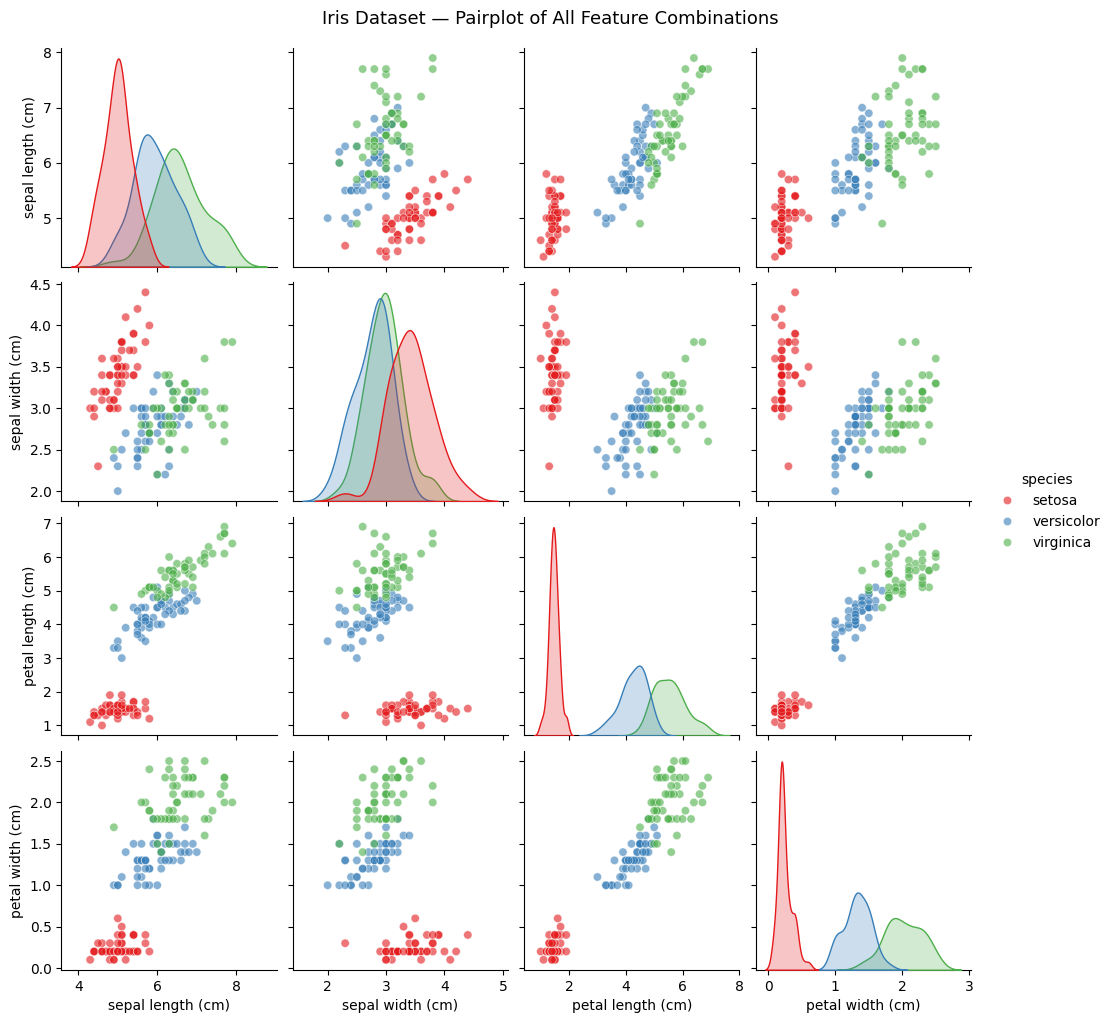


💡 Notice: Setosa (red) is clearly separable by petal length/width. Versicolor and Virginica overlap — a harder clustering challenge.


In [73]:

################################################################################
# STAGE 7
################################################################################

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

iris = load_iris()
X_iris  = iris.data           # Shape: (150, 4)
y_iris  = iris.target         # 0=Setosa, 1=Versicolor, 2=Virginica
feature_names = iris.feature_names
target_names  = iris.target_names

# Create a nice DataFrame for display
iris_df = pd.DataFrame(X_iris, columns=feature_names)
iris_df['species'] = [target_names[t] for t in y_iris]

print("🌸 Iris Dataset — First 8 rows:")
display(iris_df.head(8))

print("\n📊 Descriptive Statistics by Species:")
display(iris_df.groupby('species').mean().round(2))

# Pairplot to visualise natural structure
print("\n📈 Pairplot (coloured by true species):")
g = sns.pairplot(iris_df, hue='species', palette='Set1',
                 plot_kws={'alpha': 0.6}, diag_kind='kde')
g.fig.suptitle('Iris Dataset — Pairplot of All Feature Combinations', y=1.02, fontsize=13)
plt.show()
print("\n💡 Notice: Setosa (red) is clearly separable by petal length/width. Versicolor and Virginica overlap — a harder clustering challenge.")


################################################################################
# STAGE 8
################################################################################

---
## 📐 Stage 8: Feature Scaling & the Elbow Method

### Why We Must Scale Features Before Clustering

K-Means computes **Euclidean distances** between data points. If one feature has a range of 0–100 and another has a range of 0–1, the first feature will completely dominate the distance calculations, and K-Means will effectively ignore the second feature.

**StandardScaler** solves this by transforming each feature to have **mean = 0** and **standard deviation = 1**:

$$z = \frac{x - \mu}{\sigma}$$

After scaling, all features contribute equally to distance calculations.

### How K-Means Works

K-Means is the most widely used clustering algorithm. Here's the algorithm:
1. Choose the number of clusters `k`.
2. Randomly initialise `k` cluster centroids.
3. **Assignment step**: Assign each data point to the nearest centroid (by Euclidean distance).
4. **Update step**: Recompute each centroid as the mean of all points assigned to it.
5. Repeat steps 3–4 until centroids stop moving (convergence).

K-Means minimises the **Within-Cluster Sum of Squares (WCSS)**, also called **inertia**:

$$\text{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$

### Finding the Optimal k: The Elbow Method & Silhouette Score

K-Means requires you to specify `k` in advance, but you often don't know it. Two methods help:

**Elbow Method**: Plot WCSS for `k = 2, 3, ..., 10`. WCSS always decreases as `k` increases. We look for a "kink" or "elbow" — the point where adding another cluster stops significantly reducing WCSS.

**Silhouette Score**: For each data point, it measures how similar it is to its own cluster compared to the nearest neighbouring cluster:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Where `a(i)` = mean distance to other points in the same cluster, and `b(i)` = mean distance to points in the nearest other cluster.
- Score near **+1**: the point is well-matched to its cluster.
- Score near **0**: the point is on the boundary between two clusters.
- Score near **-1**: the point would fit better in a neighbouring cluster.

We report the **mean silhouette score** across all points. Higher is better.



Before scaling — feature means and standard deviations:
  sepal length (cm)        : mean=5.84, std=0.83
  sepal width (cm)         : mean=3.06, std=0.43
  petal length (cm)        : mean=3.76, std=1.76
  petal width (cm)         : mean=1.20, std=0.76

After StandardScaler — all features have mean≈0 and std≈1:
  sepal length (cm)        : mean=-0.0000, std=1.0000
  sepal width (cm)         : mean=-0.0000, std=1.0000
  petal length (cm)        : mean=-0.0000, std=1.0000
  petal width (cm)         : mean=-0.0000, std=1.0000


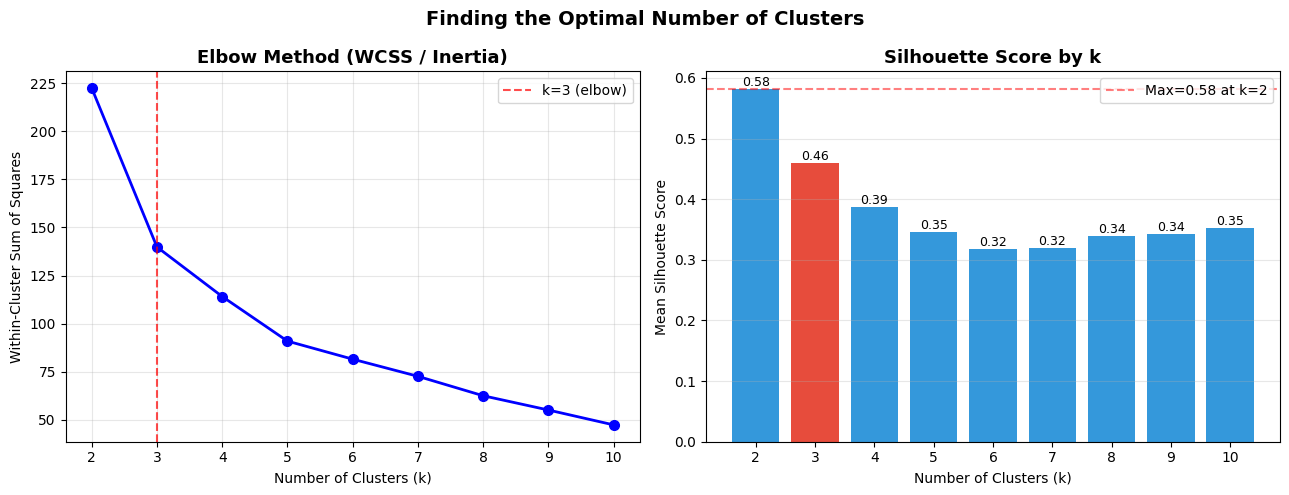

In [74]:
################################################################################
# STAGE 8
################################################################################

# Step 1: Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

print("Before scaling — feature means and standard deviations:")
for name, mean, std in zip(feature_names, X_iris.mean(axis=0), X_iris.std(axis=0)):
    print(f"  {name:25s}: mean={mean:.2f}, std={std:.2f}")

print("\nAfter StandardScaler — all features have mean≈0 and std≈1:")
for name, mean, std in zip(feature_names, X_scaled.mean(axis=0), X_scaled.std(axis=0)):
    print(f"  {name:25s}: mean={mean:+.4f}, std={std:.4f}")

# Step 2: Compute WCSS and Silhouette scores for k=2..10
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Step 3: Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(3, color='red', linestyle='--', alpha=0.7, label='k=3 (elbow)')
axes[0].set_title('Elbow Method (WCSS / Inertia)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].legend()
axes[0].grid(alpha=0.3)

bar_colors = ['#e74c3c' if k == 3 else '#3498db' for k in K_range]
axes[1].bar(K_range, silhouettes, color=bar_colors)
axes[1].set_title('Silhouette Score by k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].grid(alpha=0.3, axis='y')
for k, s in zip(K_range, silhouettes):
    axes[1].text(k, s + 0.005, f'{s:.2f}', ha='center', fontsize=9)
axes[1].axhline(max(silhouettes), color='red', linestyle='--', alpha=0.5,
                label=f'Max={max(silhouettes):.2f} at k={K_range[silhouettes.index(max(silhouettes))]}')
axes[1].legend()

plt.suptitle('Finding the Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_range[silhouettes.index(max(silhouettes))]




################################################################################
# Stage 9
################################################################################

---
## 🎯 Stage 9: Fit K-Means with k=3 and Evaluate

### Evaluating Clustering Without Labels: Silhouette Score

In a real unsupervised scenario, we have **no ground truth labels** to compare against. We rely on **internal metrics** like the silhouette score to assess quality.

### Evaluating Against True Labels: Adjusted Rand Index (ARI)

In this tutorial, we *do* have true species labels (they were just hidden during clustering). We can therefore also use an **external metric** like the **Adjusted Rand Index (ARI)**:

The Rand Index counts the fraction of pairs of points where the clustering agrees with the true labeling — both in the same cluster, or both in different clusters. The *Adjusted* version corrects for chance agreement.

- **ARI = 1.0**: Perfect agreement with true labels.
- **ARI = 0.0**: Agreement no better than random.
- **ARI < 0**: Worse than random (extremely unlikely in practice).

An ARI of ~0.73 means K-Means does a good but imperfect job — it perfectly separates *Setosa* from the others, but makes some mistakes distinguishing *Versicolor* from *Virginica* (these two species overlap in feature space as we saw in the pairplot).

In [75]:
################################################################################
# STAGE 9
################################################################################

from scipy.stats import mode

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km3.fit_predict(X_scaled)

ari = adjusted_rand_score(y_iris, labels_km)
sil = silhouette_score(X_scaled, labels_km)

print("K-Means (k=3) — Performance Metrics")
print(f"  Adjusted Rand Index (ARI)  : {ari:.4f}  (1.0 = perfect, 0.0 = random)")
print(f"  Mean Silhouette Score       : {sil:.4f}  (1.0 = perfect, 0.0 = boundary)")

# Map K-Means clusters to true species for comparison
cluster_to_species = {}
for cluster_id in range(3):
    mask = labels_km == cluster_id
    dominant_species = mode(y_iris[mask], keepdims=True).mode[0]
    cluster_to_species[cluster_id] = target_names[dominant_species]

print("\n  Cluster → Majority Species mapping:")
for cid, sname in cluster_to_species.items():
    count = (labels_km == cid).sum()
    print(f"    Cluster {cid} → {sname} ({count} flowers)")

# Confusion table
comparison = pd.DataFrame({
    'True Species': [target_names[t] for t in y_iris],
    'KMeans Cluster': [cluster_to_species[l] for l in labels_km]
})
print("\n  Cluster vs True Label Confusion Table:")
display(pd.crosstab(comparison['True Species'], comparison['KMeans Cluster']))
print("\n💡 Setosa is perfectly separated! Some Versicolor/Virginica flowers are misclassified because they overlap in 4D feature space.")


K-Means (k=3) — Performance Metrics
  Adjusted Rand Index (ARI)  : 0.6201  (1.0 = perfect, 0.0 = random)
  Mean Silhouette Score       : 0.4599  (1.0 = perfect, 0.0 = boundary)

  Cluster → Majority Species mapping:
    Cluster 0 → versicolor (53 flowers)
    Cluster 1 → setosa (50 flowers)
    Cluster 2 → virginica (47 flowers)

  Cluster vs True Label Confusion Table:


KMeans Cluster,setosa,versicolor,virginica
True Species,,,
setosa,50,0,0
versicolor,0,39,11
virginica,0,14,36



💡 Setosa is perfectly separated! Some Versicolor/Virginica flowers are misclassified because they overlap in 4D feature space.


################################################################################
# STAGE 10
################################################################################

---
## 📉 Stage 10: Principal Component Analysis (PCA) — Scree Plot

### The Curse of Dimensionality

The Iris dataset has 4 features. Humans can only visualise up to 3 dimensions easily. Many real-world datasets have dozens, hundreds, or even thousands of features. Visualising and interpreting such data is extremely difficult.

More problematically, in very high-dimensional spaces, data points tend to become equidistant from each other — a counter-intuitive property called the **"curse of dimensionality"**. This makes distance-based methods like K-Means less effective.

### What is PCA?

**Principal Component Analysis (PCA)** is a dimensionality reduction technique that finds new axes (called **principal components**) that capture the maximum variance in the data.

Mathematically, PCA computes the **eigenvectors of the covariance matrix** of the data. The eigenvector with the largest eigenvalue defines the direction of greatest variance (PC1), the next largest defines PC2 (perpendicular to PC1), and so on.

Think of it as finding the "best angles" to photograph a 3D sculpture so that the 2D photograph reveals as much of the shape as possible.

Key properties:
- PCA is **unsupervised** (it doesn't use labels).
- The principal components are **orthogonal** (uncorrelated) to each other.
- Each PC explains a decreasing amount of variance.
- You can choose how many components to keep — trading off information retention against dimensionality reduction.

### The Scree Plot

A **scree plot** shows the proportion of variance explained by each principal component. It helps you decide how many components to keep. A common rule of thumb: keep enough components to explain **≥ 95%** of the total variance.



📊 Variance Explained by Each Principal Component:
  PC1: 73.0%  ████████████████████████████████████  (Cumulative: 73.0%)
  PC2: 22.9%  ███████████  (Cumulative: 95.8%)
  PC3: 3.7%  █  (Cumulative: 99.5%)
  PC4: 0.5%    (Cumulative: 100.0%)


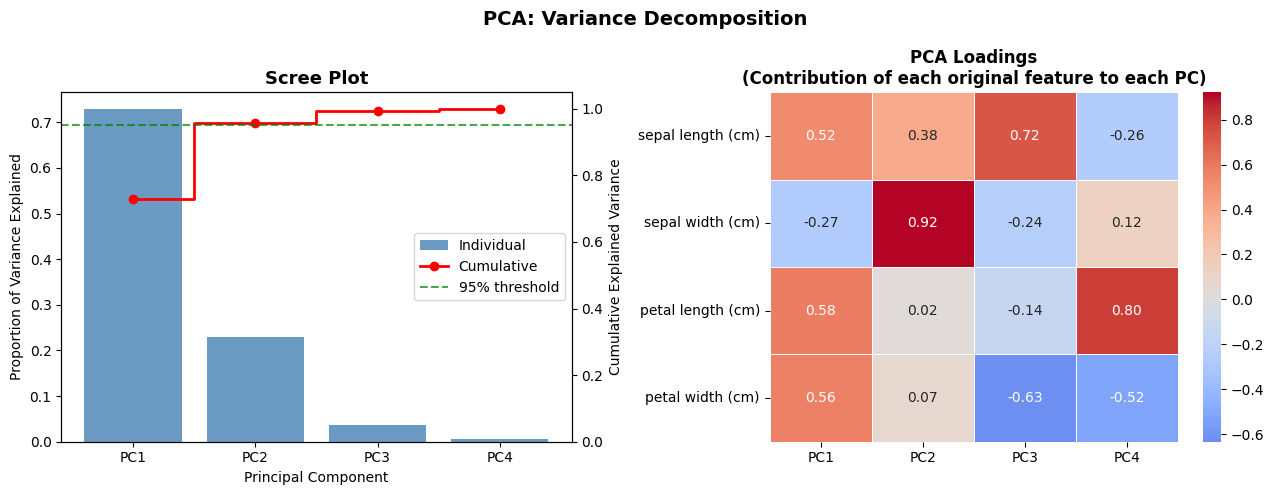


✅ 2 principal components explain 95.8% of total variance.
   PC1 is dominated by petal length and petal width — the most discriminating features.
   PC2 captures mostly sepal width variation — less discriminating but still useful.


In [76]:
################################################################################
# Stage 10
################################################################################

# Fit PCA on all 4 components first (to see the full variance breakdown)
pca_full = PCA(n_components=4, random_state=42)
pca_full.fit(X_scaled)

evr        = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

print("📊 Variance Explained by Each Principal Component:")
for i, (e, c) in enumerate(zip(evr, cumulative), 1):
    bar = '█' * int(e * 50)
    print(f"  PC{i}: {e:.1%}  {bar}  (Cumulative: {c:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pc_labels = [f'PC{i+1}' for i in range(4)]

# Bar chart + cumulative line
axes[0].bar(pc_labels, evr, color='steelblue', alpha=0.8, label='Individual')
ax2 = axes[0].twinx()
ax2.step(pc_labels, cumulative, where='mid', color='red', linewidth=2, label='Cumulative', marker='o')
ax2.axhline(0.95, color='green', linestyle='--', alpha=0.7, label='95% threshold')
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Cumulative Explained Variance')
axes[0].set_title('Scree Plot', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Proportion of Variance Explained')
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='center right')

# PCA Loadings Heatmap
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=feature_names,
    columns=pc_labels
)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('PCA Loadings\n(Contribution of each original feature to each PC)',
                  fontsize=12, fontweight='bold')

plt.suptitle('PCA: Variance Decomposition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

n_for_95 = np.argmax(cumulative >= 0.95) + 1
print(f"\n✅ {n_for_95} principal components explain {cumulative[n_for_95-1]:.1%} of total variance.")
print("   PC1 is dominated by petal length and petal width — the most discriminating features.")
print("   PC2 captures mostly sepal width variation — less discriminating but still useful.")


################################################################################
# Stage 11
################################################################################

---
## 🎨 Stage 11: Visualising K-Means Clusters in 2D PCA Space

### Why Project to 2D for Visualisation?

Our Iris data lives in 4-dimensional space. We can't directly plot it. By projecting to the first 2 principal components (which together explain ~95% of the variance), we can create a 2D scatter plot that preserves most of the structure of the original data.

### What We Expect to See

**Left plot (K-Means clusters)**: The 3 groups the algorithm discovered without any label information. Black X marks show the cluster centroids in PCA space.

**Right plot (True species)**: The true species, each represented by a different shape and colour. We can visually compare the two plots to see where K-Means succeeded and where it made mistakes.

The ARI of ~0.73 means the clusters roughly correspond to species — but some flowers near the *Versicolor/Virginica* boundary will be assigned to the wrong cluster. This is because in the raw 4D space (and even in the 2D projection), those two species genuinely overlap.

This visualisation illustrates a key lesson: **K-Means finds compact, spherical clusters**. When clusters are non-spherical, overlapping, or of different densities, other algorithms (DBSCAN, Gaussian Mixture Models, Hierarchical Clustering) may perform better.


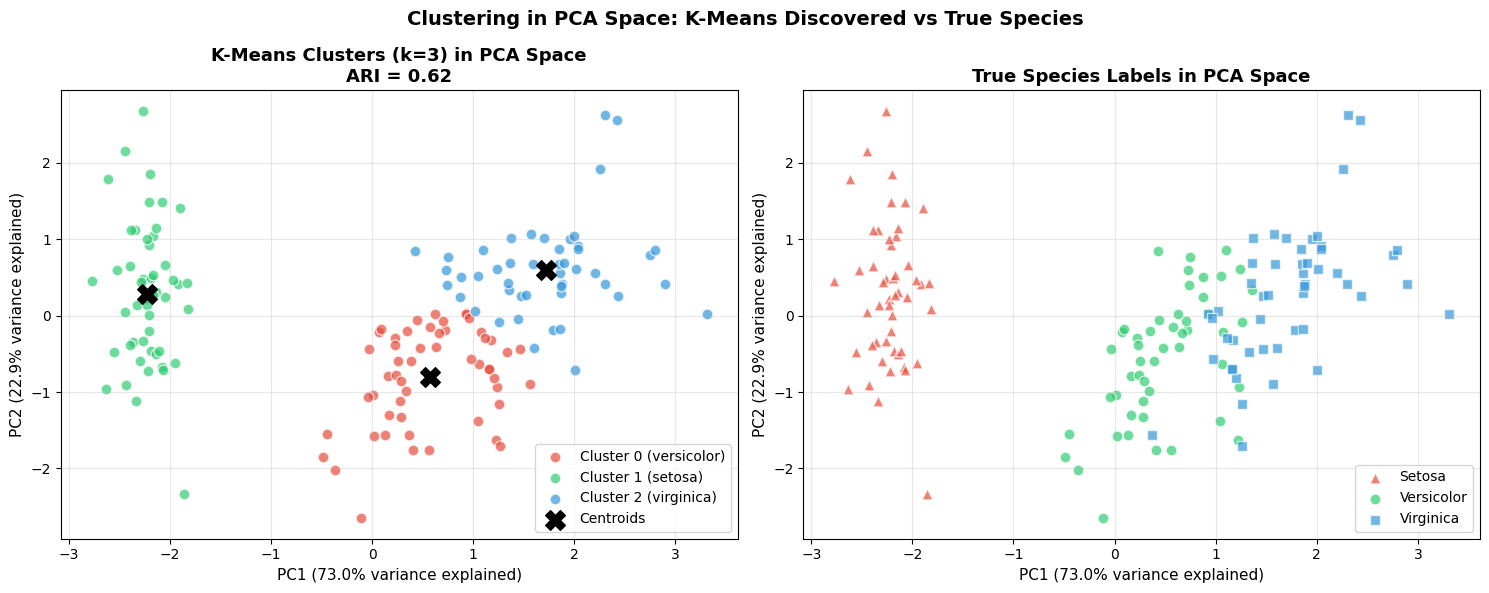


🔍 Observations:
  • The leftmost cluster (Setosa) is perfectly separated by K-Means.
  • The two right-side clusters (Versicolor & Virginica) overlap in PCA space.
  • Overall ARI = 0.62: K-Means does a good but imperfect job, limited by natural class overlap.
  • PC1 + PC2 together explain 95.8% of variance — a good 2D representation.


In [77]:
################################################################################
# Stage 11
################################################################################

# Project 4D → 2D using first 2 principal components
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

# Project centroids to PCA space for plotting
centroids_2d = pca2.transform(km3.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: K-Means Cluster Assignment
cluster_colors = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
for cluster_id in range(3):
    mask = labels_km == cluster_id
    axes[0].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id} ({cluster_to_species[cluster_id]})',
        alpha=0.7, edgecolors='w', s=60
    )

axes[0].scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroids'
)
axes[0].set_title(
    f'K-Means Clusters (k=3) in PCA Space\nARI = {ari:.2f}',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance explained)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance explained)', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: True Species Labels
species_colors  = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
species_markers = ['^', 'o', 's']
for species_id, species_name in enumerate(target_names):
    mask = y_iris == species_id
    axes[1].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=species_colors[species_id],
        label=f'{species_name.capitalize()}',
        alpha=0.7, edgecolors='w', s=60,
        marker=species_markers[species_id]
    )
axes[1].set_title('True Species Labels in PCA Space', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance explained)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance explained)', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Clustering in PCA Space: K-Means Discovered vs True Species',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🔍 Observations:")
print(f"  • The leftmost cluster (Setosa) is perfectly separated by K-Means.")
print(f"  • The two right-side clusters (Versicolor & Virginica) overlap in PCA space.")
print(f"  • Overall ARI = {ari:.2f}: K-Means does a good but imperfect job, limited by natural class overlap.")
print(f"  • PC1 + PC2 together explain {sum(pca2.explained_variance_ratio_):.1%} of variance — a good 2D representation.")


################################################################################
# SUMMARY
################################################################################

---
# 🎓 Summary & Key Takeaways

---

## Part 1: Supervised Learning (Titanic)

**Feature Engineering** is often more impactful than algorithm choice. Transforming raw data — imputing missing values, creating `family_size`, extracting `title` from a name string — gave our models more informative signals to learn from.

**The Train-Test Split** is the foundational rule of supervised learning. Never evaluate a model on the data it was trained on. Stratified splitting ensures class balance is preserved.

**Three Algorithms, different trade-offs**: Logistic Regression is fast and interpretable but linear. Random Forest aggregates many diverse trees via bagging. Gradient Boosting builds trees sequentially to correct previous errors. On tabular data, ensemble methods almost always outperform a single linear model.

**Evaluation Metrics**: Accuracy alone is misleading with imbalanced classes. Precision, recall, F1-score, and AUC give a more complete picture. ROC curves show model performance across all possible decision thresholds.

---

## Part 2: Hyperparameter Tuning

**GridSearchCV** automates the search over hyperparameter combinations using cross-validation — all on the training data. The test set must remain unseen until the very final evaluation. Using the test set for model selection constitutes **data leakage** and produces overly optimistic results.

---

## Part 3: Unsupervised Learning (Iris)

**Always scale features** before applying distance-based algorithms like K-Means. StandardScaler ensures all features contribute equally.

**Finding k** requires multiple methods: the Elbow Method and Silhouette Score complement each other. There is rarely a single "correct" answer — domain knowledge matters.

**PCA** is a powerful tool for both visualisation and preprocessing. Projecting high-dimensional data to 2D principal components allows us to visually inspect cluster structure. The scree plot and cumulative explained variance guide how many components to keep.

**K-Means has limitations**: It assumes spherical, equally sized clusters. It performs well on well-separated groups (Setosa) but struggles with overlapping classes (Versicolor vs. Virginica).

---


